# 06 — Final Visualization Compilation
**Project:** LA 2028 Olympic Games Strategic Analysis  
**Analyst:** Shabeeb | SportsFanatics Consulting  

This notebook assembles the **hero charts** for the strategic report and consulting deck. Each chart is polished to presentation standard: branded colors, clean titles, source annotations, and exported at print resolution.

### Chart Inventory (12 hero charts)
| # | Chart | Pillar |
|---|---|---|
| 1 | Games scale growth (athletes + NOCs) | City |
| 2 | Gender participation + female % trend | Athlete |
| 3 | Home advantage — host vs all others | Athlete |
| 4 | USA medal rate at home Games | Athlete |
| 5 | Cost overrun benchmarking | City |
| 6 | Legacy score vs cost scatter | City |
| 7 | LA 2028 venue map | City |
| 8 | Legacy risk radar | City |
| 9 | All-time medal choropleth | NOC |
| 10 | USA vs China rivalry | NOC |
| 11 | LA 2028 medal forecast — top 10 | Forecast |
| 12 | 2016 actual vs 2028 predicted scatter | Forecast |


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path
import logging
import warnings
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

BASE_DIR   = Path('..')
RAW_DATA   = BASE_DIR / 'data' / 'raw' / 'athlete_events.csv'
OUT_TABLES = BASE_DIR / 'outputs' / 'tables'
OUT_FIGS   = BASE_DIR / 'outputs' / 'figures'

OLY = dict(blue='#0085C7', yellow='#F4C300', black='#000000',
           green='#009F6B', red='#DF0024', bg='#F8F9FA')

PLOTLY_LAYOUT = dict(
    template='plotly_white',
    font_family='Arial',
    font_size=13,
    title_font_size=20,
    margin=dict(t=100, b=60, l=60, r=60)
)

SOURCE_NOTE = 'Source: Olympic athlete_events dataset (1896–2016) | SportsFanatics Consulting'

logger.info('Setup complete.')

INFO: Setup complete.


## 1. Load All Data & Pre-built Tables

In [2]:
df     = pd.read_csv(RAW_DATA)
summer = df[df['Season'] == 'Summer'].copy()
summer['Medal_Won'] = summer['Medal'].notna().astype(int)
summer['Gender']    = summer['Sex'].map({'M': 'Male', 'F': 'Female'})

# Pre-built tables from earlier notebooks
forecast    = pd.read_csv(OUT_TABLES / 'forecast_la2028_full.csv')
econ        = pd.read_csv(OUT_TABLES / 'city_economic_benchmarks.csv')
host_perf   = pd.read_csv(OUT_TABLES / 'city_hostNOC_performance.csv')
home_adv    = pd.read_csv(OUT_TABLES / 'athlete_homeAdvantage.csv')
risk_scores = pd.read_csv(OUT_TABLES / 'city_legacyRisk_scores.csv', index_col=0)
venues      = pd.read_csv(OUT_TABLES / 'city_la2028_venues.csv')
noc_alltime = pd.read_csv(OUT_TABLES / 'noc_alltime_medal_table.csv')

host_map = {
    1896:'GRE',1900:'FRA',1904:'USA',1908:'GBR',1912:'SWE',
    1920:'BEL',1924:'FRA',1928:'NED',1932:'USA',1936:'GER',
    1948:'GBR',1952:'FIN',1956:'AUS',1960:'ITA',1964:'JPN',
    1968:'MEX',1972:'FRG',1976:'CAN',1980:'URS',1984:'USA',
    1988:'KOR',1992:'ESP',1996:'USA',2000:'AUS',2004:'GRE',
    2008:'CHN',2012:'GBR',2016:'BRA'
}

logger.info('All data loaded.')

INFO: All data loaded.


## HERO CHART 1 — Olympic Games Scale: 120 Years of Growth

In [3]:
games_scale = (
    summer.groupby('Year')
    .agg(Athletes=('ID','nunique'), NOCs=('NOC','nunique'),
         Events=('Event','nunique'))
    .reset_index()
)

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(go.Bar(
    x=games_scale['Year'], y=games_scale['Athletes'],
    name='Athletes', marker_color=OLY['blue'], opacity=0.85
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=games_scale['Year'], y=games_scale['NOCs'],
    name='Participating NOCs', mode='lines+markers',
    line=dict(color=OLY['red'], width=2.5),
    marker=dict(size=6)
), secondary_y=True)

# LA 2028 annotation
fig.add_vline(x=2028, line_dash='dot', line_color=OLY['yellow'], line_width=2)
fig.add_annotation(
    x=2028, y=12000, text='LA 2028', showarrow=False,
    font=dict(color=OLY['yellow'], size=13, family='Arial'),
    yref='y'
)

fig.update_layout(
    title='120 Years of Olympic Growth — Athletes & Nations (Summer Games)',
    xaxis_title='Year',
    legend=dict(x=0.01, y=0.99),
    width=1200, height=620, template='plotly_white'
)
fig.update_yaxes(title_text='Unique Athletes', secondary_y=False)
fig.update_yaxes(title_text='Participating NOCs', secondary_y=True)
fig.add_annotation(
    text=SOURCE_NOTE, xref='paper', yref='paper',
    x=0, y=-0.12, showarrow=False,
    font=dict(size=10, color='gray')
)

fig.update_layout(**PLOTLY_LAYOUT)
fig.write_html(OUT_FIGS / 'HERO_01_gamesScale.html')
fig.show()
logger.info('HERO 1 saved.')

INFO: HERO 1 saved.


## HERO CHART 2 — Gender Equity Journey (1896–2016)

In [4]:
gender_yr = (
    summer.groupby(['Year','Gender'])['ID'].nunique()
    .reset_index().rename(columns={'ID':'Athletes'})
)
totals = gender_yr.groupby('Year')['Athletes'].sum().rename('Total')
gender_yr = gender_yr.join(totals, on='Year')
gender_yr['Pct'] = (gender_yr['Athletes'] / gender_yr['Total'] * 100).round(1)
female_pct = gender_yr[gender_yr['Gender']=='Female'][['Year','Pct']]

fig = make_subplots(specs=[[{'secondary_y': True}]])

for gender, color in [('Male', OLY['blue']), ('Female', OLY['red'])]:
    sub = gender_yr[gender_yr['Gender']==gender]
    fig.add_trace(go.Bar(
        x=sub['Year'], y=sub['Athletes'], name=gender,
        marker_color=color, opacity=0.8
    ), secondary_y=False)

fig.add_trace(go.Scatter(
    x=female_pct['Year'], y=female_pct['Pct'],
    name='Female %', mode='lines+markers',
    line=dict(color=OLY['yellow'], width=2.5, dash='dot'),
    marker=dict(size=7)
), secondary_y=True)

# 50% parity line
fig.add_hline(y=50, line_dash='dash', line_color='gray', opacity=0.5,
              annotation_text='50% parity', annotation_position='bottom right',
              secondary_y=True)

fig.update_layout(
    title='Gender Equity in the Olympics: 120 Years Toward Parity',
    barmode='stack', legend=dict(x=0.01, y=0.99),
    width=1200, height=620, template='plotly_white'
)
fig.update_yaxes(title_text='Unique Athletes', secondary_y=False)
fig.update_yaxes(title_text='Female Participation (%)', secondary_y=True, range=[0, 60])
fig.add_annotation(
    text=SOURCE_NOTE, xref='paper', yref='paper',
    x=0, y=-0.12, showarrow=False, font=dict(size=10, color='gray')
)
fig.update_layout(**PLOTLY_LAYOUT)
fig.write_html(OUT_FIGS / 'HERO_02_genderEquity.html')
fig.show()
logger.info('HERO 2 saved.')

INFO: HERO 2 saved.


## HERO CHART 3 — Home Advantage: The Host Nation Effect

In [5]:
home_adv['Group'] = home_adv['Is_Host'].map({1: 'Host Nation', 0: 'All Others'})

# Summary stats for callout boxes
host_avg   = home_adv[home_adv['Is_Host']==1]['Medal_Rate'].mean()
others_avg = home_adv[home_adv['Is_Host']==0]['Medal_Rate'].mean()

fig = px.line(
    home_adv, x='Year', y='Medal_Rate', color='Group',
    markers=True,
    color_discrete_map={'Host Nation': OLY['red'], 'All Others': OLY['blue']},
    labels={'Medal_Rate': 'Medal Rate (%)', 'Year': 'Games Year'},
    title='The Home Advantage Effect — Host Nation vs Rest (Summer Olympics)',
    width=1200, height=600, template='plotly_white'
)

# Average lines
fig.add_hline(y=host_avg,   line_dash='dash', line_color=OLY['red'],
              annotation_text=f'Host avg: {host_avg:.1f}%',
              annotation_position='right')
fig.add_hline(y=others_avg, line_dash='dash', line_color=OLY['blue'],
              annotation_text=f'Others avg: {others_avg:.1f}%',
              annotation_position='right')

fig.add_annotation(
    text=SOURCE_NOTE, xref='paper', yref='paper',
    x=0, y=-0.12, showarrow=False, font=dict(size=10, color='gray')
)
fig.update_layout(**PLOTLY_LAYOUT)
fig.write_html(OUT_FIGS / 'HERO_03_homeAdvantage.html')
fig.show()
logger.info('HERO 3 saved.')

INFO: HERO 3 saved.


## HERO CHART 4 — USA at Home: The LA Opportunity

In [6]:
usa = summer[summer['NOC']=='USA'].groupby('Year').agg(
    Entries=('ID','count'), Medals=('Medal_Won','sum')
).reset_index()
usa['Medal_Rate'] = (usa['Medals'] / usa['Entries'] * 100).round(2)
usa['Host'] = usa['Year'].isin([1904,1932,1984,1996])

fig = px.bar(
    usa, x='Year', y='Medal_Rate',
    color='Host',
    color_discrete_map={True: OLY['red'], False: OLY['blue']},
    labels={'Medal_Rate':'Medal Rate (%)', 'Host':'Home Games'},
    title='USA Medal Rate at Every Summer Olympics — Home Games Highlighted',
    width=1200, height=580, template='plotly_white'
)

# Annotate home Games
for year, label in [(1904,'St. Louis\n1904'),(1932,'LA 1932'),(1984,'LA 1984'),(1996,'Atlanta\n1996')]:
    row = usa[usa['Year']==year]
    if not row.empty:
        fig.add_annotation(
            x=year, y=row['Medal_Rate'].values[0]+0.8,
            text=label.replace('\n','<br>'),
            showarrow=False, font=dict(size=10, color=OLY['red'])
        )

# LA 2028 projected
fig.add_vline(x=2028, line_dash='dot', line_color=OLY['yellow'], line_width=2)
fig.add_annotation(
    x=2028, y=usa['Medal_Rate'].max()*0.9,
    text='LA 2028<br>(projected)', showarrow=False,
    font=dict(color=OLY['yellow'], size=12)
)
fig.add_annotation(
    text=SOURCE_NOTE, xref='paper', yref='paper',
    x=0, y=-0.12, showarrow=False, font=dict(size=10, color='gray')
)
fig.update_layout(**PLOTLY_LAYOUT)
fig.write_html(OUT_FIGS / 'HERO_04_usaAtHome.html')
fig.show()
logger.info('HERO 4 saved.')

INFO: HERO 4 saved.


## HERO CHART 5 — Cost Overrun: LA 2028 vs History

In [7]:
overrun = econ.dropna(subset=['Cost_Overrun_pct']).sort_values('Cost_Overrun_pct')

colors = overrun['Cost_Overrun_pct'].apply(
    lambda x: OLY['green'] if x == 0 else (OLY['yellow'] if x < 80 else OLY['red'])
)

fig = go.Figure(go.Bar(
    x=overrun['Cost_Overrun_pct'],
    y=overrun['Label'],
    orientation='h',
    marker_color=colors,
    text=[f'+{x:.0f}%' if x > 0 else 'On budget' for x in overrun['Cost_Overrun_pct']],
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Overrun: %{x:.0f}%<extra></extra>'
))

fig.update_layout(
    title='Olympic Cost Overruns: Every Modern Games vs Budget<br>'
          '<sup>Green = on/under budget | Yellow = moderate | Red = severe overrun</sup>',
    xaxis_title='Cost Overrun (%)',
    xaxis=dict(range=[0, overrun['Cost_Overrun_pct'].max() * 1.2]),
    width=1100, height=620, template='plotly_white'
)
fig.add_annotation(
    text=SOURCE_NOTE + ' | Oxford Olympic Study 2024',
    xref='paper', yref='paper',
    x=0, y=-0.10, showarrow=False, font=dict(size=10, color='gray')
)
fig.update_layout(**PLOTLY_LAYOUT)
fig.write_html(OUT_FIGS / 'HERO_05_costOverrun.html')
fig.show()
logger.info('HERO 5 saved.')

INFO: HERO 5 saved.


## HERO CHART 6 — Legacy Score vs Cost: Where LA 2028 Should Land

In [8]:
legacy = econ.dropna(subset=['Legacy_Score','Cost_Overrun_pct']).copy()

fig = px.scatter(
    legacy,
    x='Cost_Overrun_pct', y='Legacy_Score',
    size='Actual_Cost_USD_B', color='Label',
    text='Label',
    labels={'Cost_Overrun_pct':'Cost Overrun (%)', 'Legacy_Score':'Legacy Score (1–10)'},
    title='Cost Discipline vs Legacy Outcome — Summer Olympic Host Cities<br>'
          '<sup>Bubble = actual cost (USD B) | LA 2028 target zone shaded</sup>',
    width=1100, height=680, template='plotly_white'
)
fig.update_traces(textposition='top center', textfont_size=10)
fig.update_layout(showlegend=False)

# Target zone
fig.add_shape(type='rect', x0=0, x1=60, y0=7, y1=10.5,
    fillcolor=OLY['green'], opacity=0.08,
    line=dict(color=OLY['green'], dash='dot', width=2)
)
fig.add_annotation(x=30, y=10.3, text='<b>LA 2028 Target Zone</b>',
    showarrow=False, font=dict(color=OLY['green'], size=12))

# Barcelona & Sydney call-outs
for city, note in [('Barcelona 1992','Urban gold standard'),
                   ('Sydney 2000','Best Games ever'),
                   ('Los Angeles 1984','Only profitable Games')]:
    row = legacy[legacy['Label']==city]
    if not row.empty:
        fig.add_annotation(
            x=row['Cost_Overrun_pct'].values[0],
            y=row['Legacy_Score'].values[0] - 0.6,
            text=f'<i>{note}</i>', showarrow=False,
            font=dict(size=9, color='gray')
        )

fig.add_annotation(
    text=SOURCE_NOTE + ' | Oxford Olympic Study 2024',
    xref='paper', yref='paper',
    x=0, y=-0.12, showarrow=False, font=dict(size=10, color='gray')
)
fig.update_layout(**PLOTLY_LAYOUT)
fig.write_html(OUT_FIGS / 'HERO_06_legacyVsCost.html')
fig.show()
logger.info('HERO 6 saved.')

INFO: HERO 6 saved.


## HERO CHART 7 — LA 2028 Venue Map

In [9]:
fig = px.scatter_mapbox(
    venues,
    lat='Lat', lon='Lon',
    color='Cluster',
    size='Capacity',
    hover_name='Venue',
    hover_data={'Sport':True,'Capacity':True,'Status':True,'Lat':False,'Lon':False},
    title='LA 2028 Olympic Venues — Zero New Permanent Builds',
    mapbox_style='carto-positron',
    center={'lat':34.05,'lon':-118.25}, zoom=9,
    width=1200, height=720
)
fig.update_layout(
    font_family='Arial', title_font_size=20,
    margin=dict(t=80, b=40, l=20, r=20)
)
fig.add_annotation(
    text='All 28 venues are existing or temporary structures | ' + SOURCE_NOTE,
    xref='paper', yref='paper',
    x=0, y=-0.04, showarrow=False, font=dict(size=10, color='gray')
)
fig.write_html(OUT_FIGS / 'HERO_07_la2028VenueMap.html')
fig.show()
logger.info('HERO 7 saved.')

INFO: HERO 7 saved.


## HERO CHART 8 — Legacy Risk Radar: LA 2028 vs Comparators

In [10]:
risk_dimensions = [
    'Cost Overrun Risk','Venue Legacy Risk','Political Risk',
    'Infrastructure Burden','Environmental Risk','Security Risk'
]

risk_profiles = {
    'LA 1984':     [1, 1, 2, 1, 3, 4],
    'Athens 2004': [9,10, 5, 9, 6, 7],
    'Rio 2016':    [8, 9, 9, 8, 8, 8],
    'Paris 2024':  [5, 2, 3, 3, 5, 6],
    'LA 2028 Est': [3, 1, 2, 2, 4, 5],
}

colors_radar = [OLY['green'], OLY['red'], OLY['yellow'], OLY['blue'], '#9B59B6']

fig = go.Figure()
for (city, scores), color in zip(risk_profiles.items(), colors_radar):
    width = 3 if 'LA 2028' in city else 1.5
    fig.add_trace(go.Scatterpolar(
        r=scores + [scores[0]],
        theta=risk_dimensions + [risk_dimensions[0]],
        fill='toself', name=city,
        line=dict(color=color, width=width),
        opacity=0.65 if 'LA 2028' not in city else 0.85
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,10],
                               tickfont_size=10)),
    title='Host City Risk Profile — LA 2028 vs Comparators<br>'
          '<sup>1 = Low Risk | 10 = High Risk | LA 2028 in purple</sup>',
    font_family='Arial', title_font_size=18,
    width=820, height=680,
    legend=dict(x=1.08, y=0.9)
)
fig.write_html(OUT_FIGS / 'HERO_08_riskRadar.html')
fig.show()
logger.info('HERO 8 saved.')

INFO: HERO 8 saved.


## HERO CHART 9 — All-Time Olympic Medal Map

In [11]:
noc_to_iso3 = {
    'USA':'USA','URS':'RUS','GBR':'GBR','FRA':'FRA','GER':'DEU','AUS':'AUS',
    'ITA':'ITA','HUN':'HUN','SWE':'SWE','CHN':'CHN','RUS':'RUS','JPN':'JPN',
    'FIN':'FIN','NOR':'NOR','KOR':'KOR','CUB':'CUB','GDR':'DEU','NED':'NLD',
    'BUL':'BGR','CAN':'CAN','ROM':'ROU','POL':'POL','DEN':'DNK','TCH':'CZE',
    'BRA':'BRA','KEN':'KEN','JAM':'JAM','NZL':'NZL','ESP':'ESP','ARG':'ARG',
    'ETH':'ETH','MEX':'MEX','UKR':'UKR','BLR':'BLR','GRE':'GRC','ZIM':'ZWE',
    'CZE':'CZE','BAH':'BHS','RSA':'ZAF','TUR':'TUR','AUT':'AUT','SUI':'CHE',
    'PRK':'PRK','IRI':'IRN','INA':'IDN','MAR':'MAR','COL':'COL','GEO':'GEO',
    'NGR':'NGA','EGY':'EGY','IND':'IND','THA':'THA','UZB':'UZB','SVK':'SVK',
    'CRO':'HRV','MGL':'MNG','AZE':'AZE','KAZ':'KAZ','TUN':'TUN','POR':'PRT',
    'BEL':'BEL','VEN':'VEN','PUR':'PRI','SRB':'SRB','LTU':'LTU','TPE':'TWN',
}

noc_alltime['ISO3'] = noc_alltime['NOC'].map(noc_to_iso3)
choropleth_data = noc_alltime.dropna(subset=['ISO3']).copy()

fig = px.choropleth(
    choropleth_data,
    locations='ISO3',
    color='Total',
    hover_name='NOC',
    hover_data={'Gold':True,'Silver':True,'Bronze':True,'Total':True,'ISO3':False},
    color_continuous_scale=[
        [0, OLY['bg']], [0.05, '#BDE3F5'],
        [0.3, OLY['blue']], [0.7, OLY['green']], [1, OLY['red']]
    ],
    title='All-Time Summer Olympic Medal Count by Country (1896–2016)',
    width=1200, height=640
)
fig.update_layout(
    font_family='Arial', title_font_size=19,
    geo=dict(showframe=False, showcoastlines=True,
             projection_type='natural earth'),
    margin=dict(t=80, b=50, l=10, r=10)
)
fig.add_annotation(
    text=SOURCE_NOTE, xref='paper', yref='paper',
    x=0, y=-0.08, showarrow=False, font=dict(size=10, color='gray')
)
fig.write_html(OUT_FIGS / 'HERO_09_allTimeMedalMap.html')
fig.show()
logger.info('HERO 9 saved.')

INFO: HERO 9 saved.


## HERO CHART 10 — USA vs China: The Modern Rivalry

In [12]:
rivalry = (
    summer[(summer['NOC'].isin(['USA','CHN'])) & (summer['Year']>=1984)]
    .groupby(['Year','NOC','Medal'])['ID']
    .count().reset_index().rename(columns={'ID':'Count'})
)

total_r = rivalry.groupby(['Year','NOC'])['Count'].sum().reset_index()
gold_r  = rivalry[rivalry['Medal']=='Gold'].groupby(['Year','NOC'])['Count'].sum().reset_index()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Total Medals', 'Gold Medals Only']
)

for df_in, col in [(total_r, 1), (gold_r, 2)]:
    for noc, color in [('USA', OLY['blue']), ('CHN', OLY['red'])]:
        sub = df_in[df_in['NOC']==noc]
        val_col = 'Count'
        fig.add_trace(go.Scatter(
            x=sub['Year'], y=sub[val_col],
            name=noc, mode='lines+markers',
            line=dict(color=color, width=2.5),
            marker=dict(size=8),
            legendgroup=noc,
            showlegend=(col==1)
        ), row=1, col=col)

# Beijing 2008 — China peaks on gold
fig.add_vline(x=2008, line_dash='dot', line_color='gray', opacity=0.6)
fig.add_annotation(x=2008, y=51, text='Beijing<br>2008',
    showarrow=False, font=dict(size=10, color='gray'), row=1, col=2)

fig.update_layout(
    title='USA vs China: The Olympic Rivalry (1984–2016)',
    width=1200, height=580, template='plotly_white',
    legend=dict(x=0.45, y=0.98)
)
fig.add_annotation(
    text=SOURCE_NOTE, xref='paper', yref='paper',
    x=0, y=-0.12, showarrow=False, font=dict(size=10, color='gray')
)
fig.update_layout(**PLOTLY_LAYOUT)
fig.write_html(OUT_FIGS / 'HERO_10_usaChinaRivalry.html')
fig.show()
logger.info('HERO 10 saved.')

INFO: HERO 10 saved.


## HERO CHART 11 — LA 2028 Medal Forecast: Top 10 Nations

In [13]:
top10 = forecast.head(10).copy()
top10.columns = ['NOC','Medals_2016','Pred_2028','Low','High','Is_Host','Rank','Delta']

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Predicted 2028',
    x=top10['NOC'], y=top10['Pred_2028'],
    marker_color=[OLY['red'] if h==1 else OLY['blue'] for h in top10['Is_Host']],
    error_y=dict(
        type='data', symmetric=False,
        array=      top10['High'] - top10['Pred_2028'],
        arrayminus= top10['Pred_2028'] - top10['Low']
    ),
    text=[f'{int(v)}' for v in top10['Pred_2028']],
    textposition='outside',
    textfont=dict(size=13, family='Arial')
))

fig.add_trace(go.Scatter(
    name='Rio 2016 Actual',
    x=top10['NOC'], y=top10['Medals_2016'],
    mode='markers',
    marker=dict(symbol='diamond', size=14, color=OLY['yellow'],
                line=dict(color='black', width=1.5))
))

fig.update_layout(
    title='LA 2028 Medal Count Forecast — Top 10 Nations<br>'
          '<sup>Error bars = model confidence interval | '
          'Diamonds = Rio 2016 actual | Red = USA (host nation)</sup>',
    yaxis_title='Total Medals',
    width=1100, height=620, template='plotly_white'
)
fig.add_annotation(
    text='Forecast: Ensemble (Random Forest + Gradient Boosting) | '
         'Trained on 1988–2016 Summer Olympics | ' + SOURCE_NOTE,
    xref='paper', yref='paper',
    x=0, y=-0.14, showarrow=False, font=dict(size=10, color='gray')
)
fig.update_layout(**PLOTLY_LAYOUT)
fig.write_html(OUT_FIGS / 'HERO_11_medalForecastTop10.html')
fig.show()
logger.info('HERO 11 saved.')

INFO: HERO 11 saved.


## HERO CHART 12 — 2016 vs 2028: Who's Moving Up?

In [14]:
compare = forecast.head(25).copy()
compare.columns = ['NOC','Medals_2016','Pred_2028','Low','High','Is_Host','Rank','Delta']
compare['Direction'] = compare['Delta'].apply(
    lambda d: 'Up ↑' if d > 3 else ('Down ↓' if d < -3 else 'Stable →')
)

color_map = {'Up ↑': OLY['green'], 'Down ↓': OLY['red'], 'Stable →': OLY['blue']}

fig = px.scatter(
    compare,
    x='Medals_2016', y='Pred_2028',
    color='Direction',
    size=compare['Delta'].abs() + 8,
    text='NOC',
    color_discrete_map=color_map,
    labels={'Medals_2016':'Actual Medals (Rio 2016)', 'Pred_2028':'Predicted Medals (LA 2028)'},
    title='From Rio 2016 to LA 2028: Who Rises, Who Falls?<br>'
          '<sup>Above line = predicted improvement | Bubble size = magnitude of change</sup>',
    width=1100, height=720, template='plotly_white'
)
fig.update_traces(textposition='top center', textfont_size=10)

# Identity line
max_v = max(compare['Medals_2016'].max(), compare['Pred_2028'].max()) + 15
fig.add_trace(go.Scatter(
    x=[0, max_v], y=[0, max_v],
    mode='lines', name='No change',
    line=dict(color='lightgray', dash='dash', width=1.5),
    showlegend=True
))

fig.add_annotation(
    text=SOURCE_NOTE,
    xref='paper', yref='paper',
    x=0, y=-0.13, showarrow=False, font=dict(size=10, color='gray')
)
fig.update_layout(**PLOTLY_LAYOUT)
fig.write_html(OUT_FIGS / 'HERO_12_2016vs2028Scatter.html')
fig.show()
logger.info('HERO 12 saved.')

INFO: HERO 12 saved.


## Static PNG — Summary Dashboard (Matplotlib)

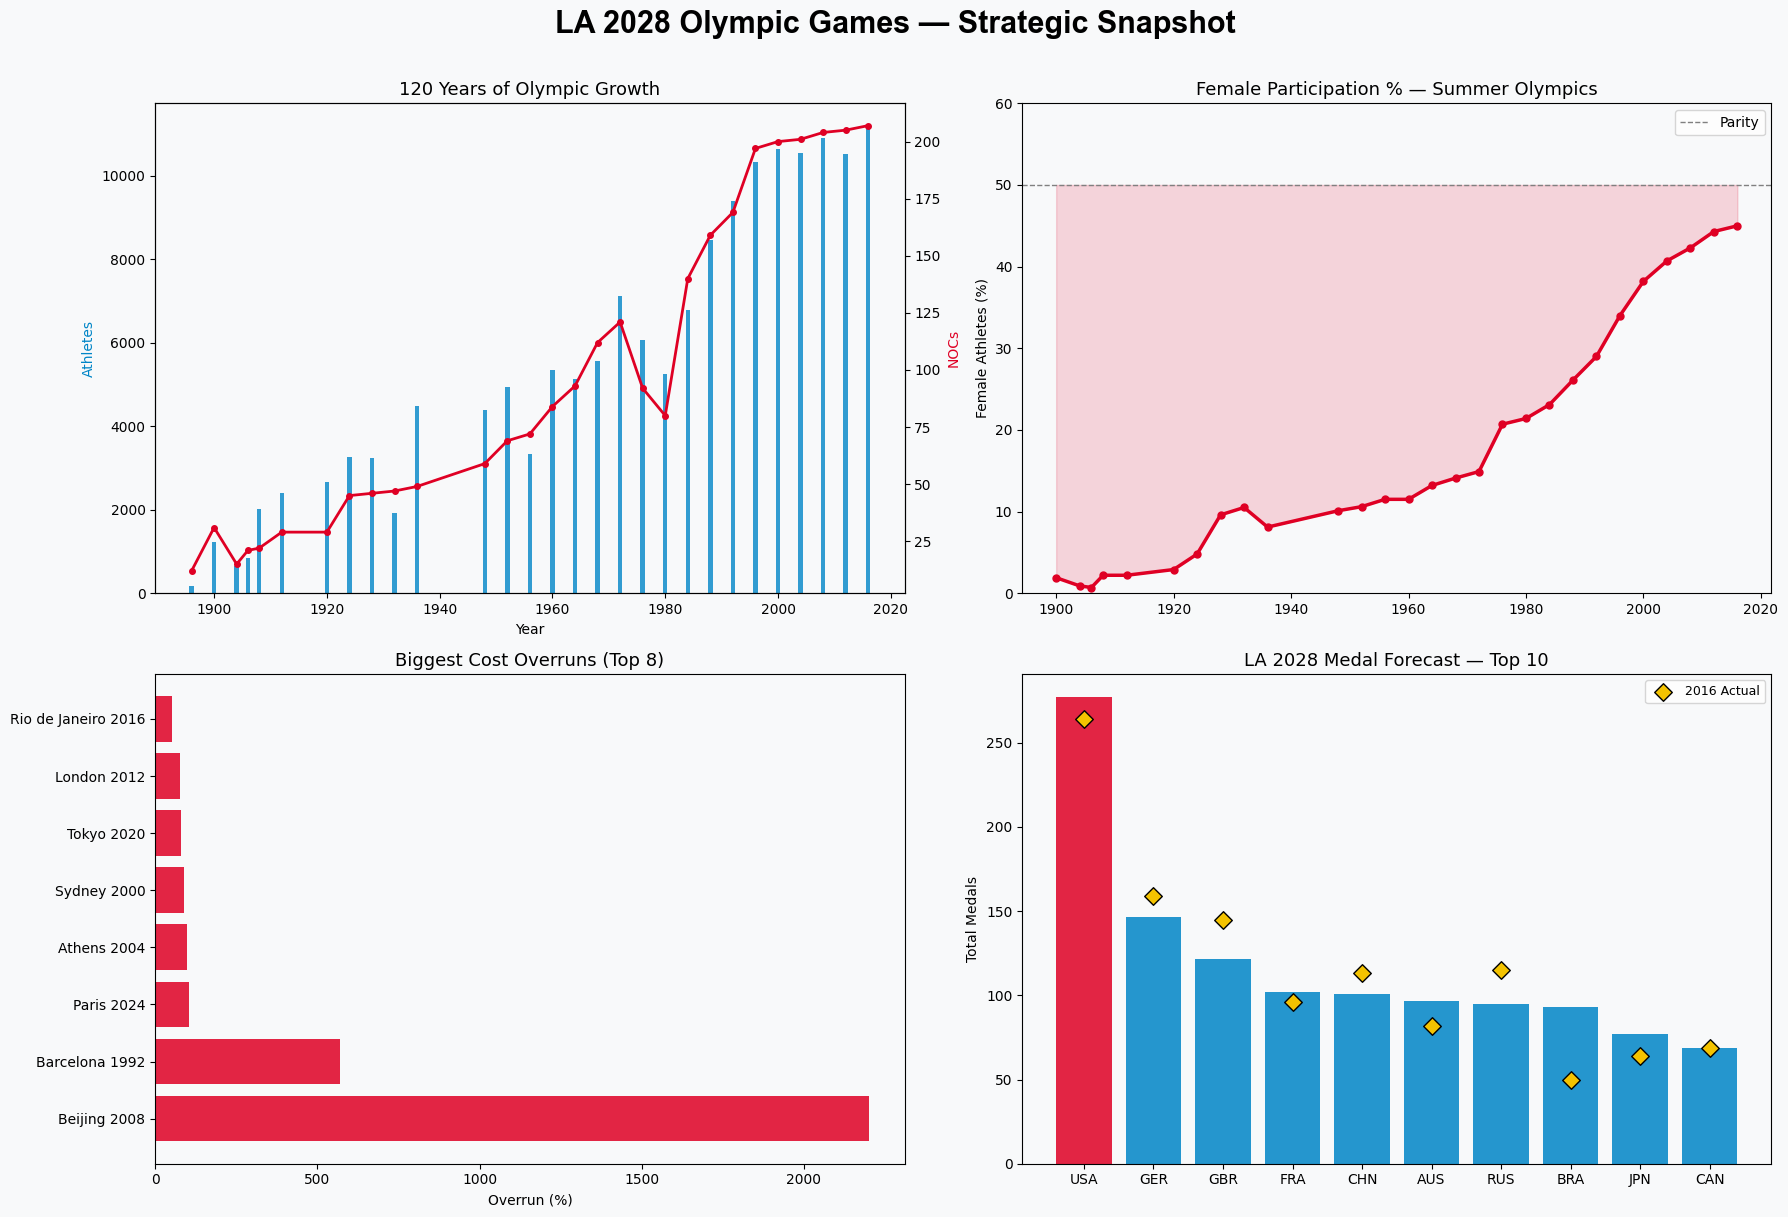

INFO: Static summary dashboard saved at 300 DPI.


In [15]:
# 2×2 static summary for report embedding
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(OLY['bg'])
fig.suptitle('LA 2028 Olympic Games — Strategic Snapshot',
             fontsize=22, fontname='Arial', fontweight='bold', y=1.01)

# Panel A — Games scale
ax = axes[0, 0]
ax.bar(games_scale['Year'], games_scale['Athletes'],
       color=OLY['blue'], alpha=0.8, label='Athletes')
ax2 = ax.twinx()
ax2.plot(games_scale['Year'], games_scale['NOCs'],
         color=OLY['red'], linewidth=2, marker='o', markersize=4, label='NOCs')
ax.set_title('120 Years of Olympic Growth', fontsize=13)
ax.set_xlabel('Year'); ax.set_ylabel('Athletes', color=OLY['blue'])
ax2.set_ylabel('NOCs', color=OLY['red'])
ax.set_facecolor(OLY['bg'])

# Panel B — Gender pct
ax = axes[0, 1]
fp = female_pct.set_index('Year')['Pct']
ax.plot(fp.index, fp.values, color=OLY['red'], linewidth=2.5, marker='o', markersize=5)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Parity')
ax.fill_between(fp.index, fp.values, 50, where=(fp.values < 50),
                alpha=0.15, color=OLY['red'])
ax.set_title('Female Participation % — Summer Olympics', fontsize=13)
ax.set_ylabel('Female Athletes (%)')
ax.set_ylim(0, 60); ax.set_facecolor(OLY['bg'])
ax.legend()

# Panel C — Cost overrun top cities
ax = axes[1, 0]
top_overrun = overrun.sort_values('Cost_Overrun_pct', ascending=False).head(8)
bar_colors = [OLY['green'] if x==0 else OLY['red'] for x in top_overrun['Cost_Overrun_pct']]
ax.barh(top_overrun['Label'], top_overrun['Cost_Overrun_pct'], color=bar_colors, alpha=0.85)
ax.set_title('Biggest Cost Overruns (Top 8)', fontsize=13)
ax.set_xlabel('Overrun (%)')
ax.set_facecolor(OLY['bg'])

# Panel D — Forecast top 10
ax = axes[1, 1]
t10_plot = top10.head(10)
bar_c = [OLY['red'] if h==1 else OLY['blue'] for h in t10_plot['Is_Host']]
ax.bar(t10_plot['NOC'], t10_plot['Pred_2028'], color=bar_c, alpha=0.85)
ax.scatter(t10_plot['NOC'], t10_plot['Medals_2016'],
           color=OLY['yellow'], zorder=5, s=80, marker='D',
           edgecolors='black', linewidths=1, label='2016 Actual')
ax.set_title('LA 2028 Medal Forecast — Top 10', fontsize=13)
ax.set_ylabel('Total Medals')
ax.legend(fontsize=9); ax.set_facecolor(OLY['bg'])

plt.tight_layout()
plt.savefig(OUT_FIGS / 'HERO_summary_dashboard.png', dpi=300, bbox_inches='tight',
            facecolor=OLY['bg'])
plt.show()
logger.info('Static summary dashboard saved at 300 DPI.')

## Chart Inventory — Final Export Check

In [16]:
import os

all_figs = sorted(OUT_FIGS.glob('*'))
hero_figs = [f for f in all_figs if f.name.startswith('HERO')]
pillar_figs = [f for f in all_figs if not f.name.startswith('HERO')]

print(f'HERO charts (presentation-ready): {len(hero_figs)}')
for f in hero_figs:
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:55s}  {size_kb:6.0f} KB')

print(f'\nPillar analysis charts: {len(pillar_figs)}')
for f in pillar_figs:
    print(f'  {f.name}')

all_tables = sorted(OUT_TABLES.glob('*.csv'))
print(f'\nData tables: {len(all_tables)}')
for t in all_tables:
    print(f'  {t.name}')

logger.info('Visualization compilation complete.')

INFO: Visualization compilation complete.


HERO charts (presentation-ready): 13
  HERO_01_gamesScale.html                                    4734 KB
  HERO_02_genderEquity.html                                  4735 KB
  HERO_03_homeAdvantage.html                                 4736 KB
  HERO_04_usaAtHome.html                                     4735 KB
  HERO_05_costOverrun.html                                   4734 KB
  HERO_06_legacyVsCost.html                                  4741 KB
  HERO_07_la2028VenueMap.html                                4741 KB
  HERO_08_riskRadar.html                                     4735 KB
  HERO_09_allTimeMedalMap.html                               4736 KB
  HERO_10_usaChinaRivalry.html                               4735 KB
  HERO_11_medalForecastTop10.html                            4735 KB
  HERO_12_2016vs2028Scatter.html                             4736 KB
  HERO_summary_dashboard.png                                  511 KB

Pillar analysis charts: 41
  athlete_bar_genderParticipation.html

## Summary — Visualization Compilation Complete

| Deliverable | Count | Format |
|---|---|---|
| Hero charts (presentation) | 12 | Interactive HTML |
| Summary dashboard | 1 | Static PNG 300 DPI |
| Pillar analysis charts | 30+ | Interactive HTML |
| Data tables | 20+ | CSV |

### Ready for
- **Report:** Embed hero charts and summary PNG
- **Deck:** Copy charts directly from HTML into PowerPoint via screenshot/export
- **Dashboard:** All data tables ready as Streamlit data sources

**Next step → Written strategic report**